# Libraries

In [24]:
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Generating dataset 

In [2]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    random_state=42,
    centers=4
)

<Axes: >

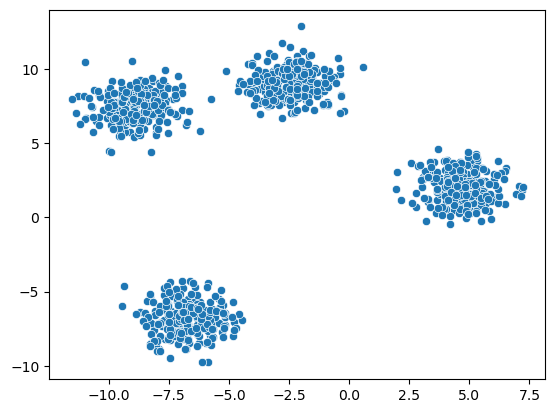

In [3]:
sns.scatterplot(x=X[:,0],
                y=X[:,1])

# K-Means

In [4]:
k = 4
Km = KMeans(
    n_clusters=k,
    init='k-means++',
    random_state=42,
)

In [5]:
labels = Km.fit_predict(X)

X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


<Axes: >

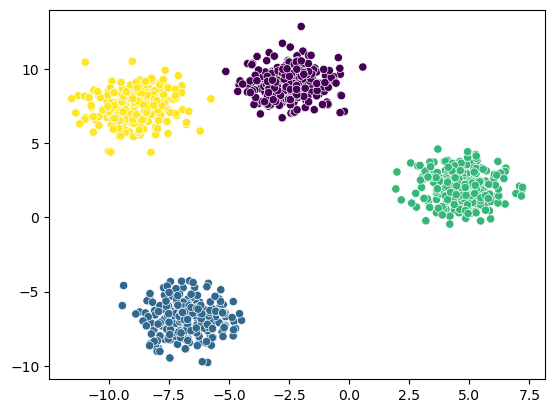

In [6]:
sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
    c=labels
)

# Choose K value

# Elbow Method

In [7]:
wcss = []
for k in range(1,21):
    Km = KMeans(n_clusters=k)
    Km.fit_predict(X)
    wcss.append(Km.inertia_)


X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less 

<Axes: >

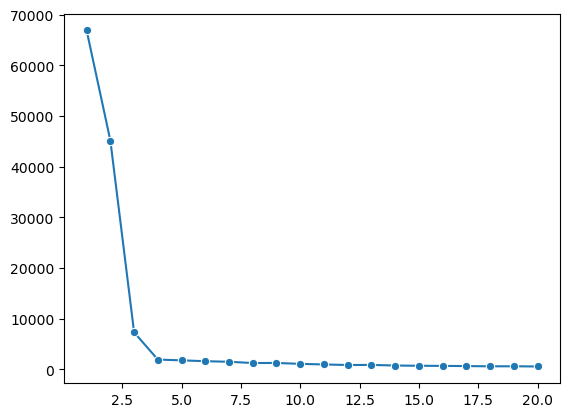

In [8]:
sns.lineplot(
    x=range(1,21),
    y=wcss,
    marker='o'
)

In [9]:
# Kneed Locator
kn = KneeLocator(range(1,21),wcss, curve="convex", direction="decreasing")
print(kn.elbow)

4


# Silhouette score

In [10]:
ss = []
for k in range(2,21):
    Km = KMeans(n_clusters=k)
    labels = Km.fit_predict(X)
    score = silhouette_score(X,labels)
    ss.append(score)
    # print(ss)

X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less 

<Axes: >

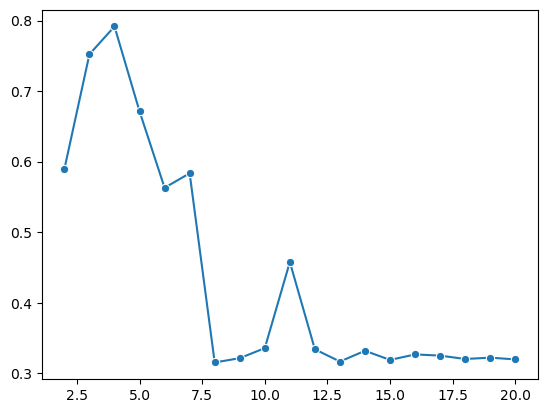

In [11]:
# plot - K and SS
sns.lineplot(x=range(2,21), y=ss, marker='o')

# K-Means for Iris Dataset

In [12]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [13]:
iris = load_iris()
X = iris.data
# X.columns = iris.feature_names
y = iris.target

In [14]:
X.shape

(150, 4)

<Axes: >

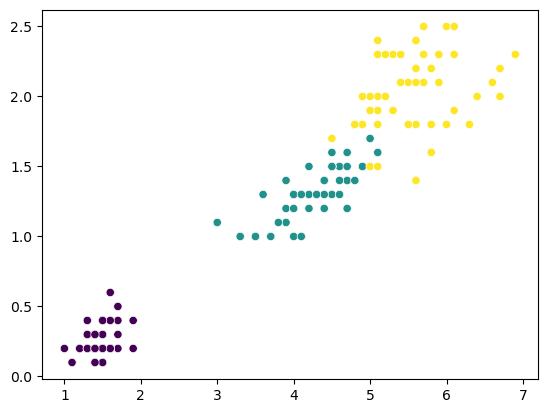

In [15]:
# Visualize
sns.scatterplot(
    x=X[:,2],
    y=X[:,3],
    c=y
)

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
wcss = []
for k in range(1,11):
    km = KMeans(n_clusters=k)
    km.fit_transform(X_scaled)
    wcss.append(km.inertia_)


X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less 

<Axes: >

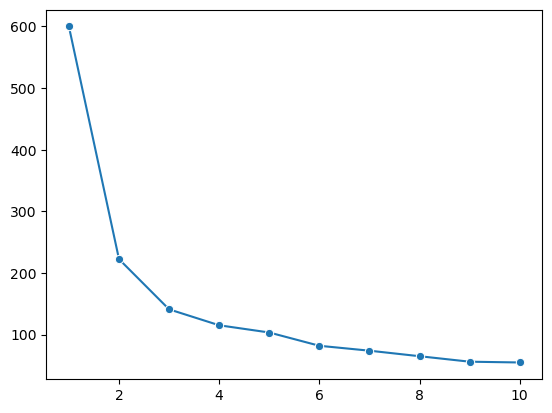

In [19]:
sns.lineplot(
    x=range(1,11),
    y=wcss,
    marker='o'
)

X:\AnacondaFiles\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

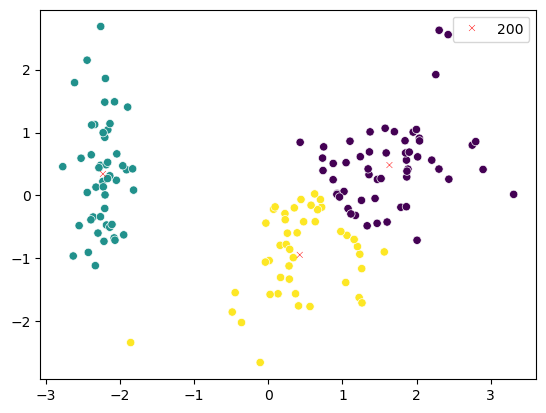

In [45]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

km = KMeans(n_clusters=3, random_state=10)
label = km.fit_predict(pca_data)

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    c=label
)
sns.scatterplot(
    x=km.cluster_centers_[:,0],
    y=km.cluster_centers_[:,1],
    marker='x',
    color="red",
    size=200
)